For using Colab GPU, preprocessed data are saved at Google Drive at Folder ML_project

In [25]:
from google.colab import drive
drive.mount('/content/drive')
drive_path = '/content/drive/MyDrive/ML_project/' # For MGA

import numpy as np

# Adjust 'ML_Project' if you named your Drive folder something else!
file_path = drive_path + 'processed_train_data.npz'

# Load the preprocessed data
data = np.load(file_path)
x_train_full = data['x'] 
y_train_full = data['y'] 

# Normalize pixel values
x_train_full = x_train_full.astype('float32') / 255.0

print(f"Loaded training data shape: {x_train_full.shape}")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded training data shape: (9227, 51, 45, 1)


In [26]:
y_train = y_train_full
X_train = x_train_full

test_data_path = drive_path + 'processed_test_data.npz' 
test_data = np.load(test_data_path)
x_test = test_data['x'].astype('float32') / 255.0
test_ids = test_data['ids'].astype(int) - 1 # Adjust IDs to be correctly indexed 



In [27]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

def build_multiclass_cnn_with_aug(input_shape=(51, 45, 1)):
    model = models.Sequential()

    # ==========================================
    # --- DATA AUGMENTATION BLOCK ---
    # This block is ONLY active during model.fit()
    # ==========================================
    
    # 1. Random Translation (Shift): 
    # Shifts the image horizontally by up to +/- 10% and vertically by up to +/- 10%
    model.add(layers.RandomTranslation(height_factor=0.05, width_factor=0.05, fill_mode='nearest', input_shape=input_shape))
    
    # 2. Gaussian Noise:
    # Simulates the sensor noise and reflections mentioned in the assignment.
    # The stddev value (0.05) might need tuning depending on how your data is normalized. 
    # If your pixels are 0 to 1, 0.05 is a good start.
    model.add(layers.GaussianNoise(stddev=0.005))

    # ==========================================
    # --- FEATURE EXTRACTION BLOCKS ---
    # ==========================================
    model.add(layers.Conv2D(32, kernel_size=(3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.25))

    model.add(layers.Conv2D(64, kernel_size=(3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.25))

    model.add(layers.Conv2D(128, kernel_size=(5, 5), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.1))
    
    # --- Block 4 (New) ---
    model.add(layers.Conv2D(256, kernel_size=(3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.25))

    # ==========================================
    # --- FULLY CONNECTED CLASSIFIER ---
    # ==========================================
    model.add(layers.Flatten())
    
    model.add(layers.Dense(1024))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('gelu'))
    model.add(layers.Dropout(0.2))
    
    model.add(layers.Dense(256))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.25))

    model.add(layers.Dense(64))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.3)) 

    # ==========================================
    # --- OUTPUT LAYER ---
    # ==========================================
    # 4 units (Classes: 0, 1, 2, 3) using Softmax
    model.add(layers.Dense(4, activation='softmax'))
    
    return model

# Build the model
multiclass_model = build_multiclass_cnn_with_aug()

# Compile the model
# Remember: Since your labels are single integers (0, 1, 2, 3), you MUST use sparse_categorical_crossentropy
multiclass_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

multiclass_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_translation_4            │ (None, 51, 45, 1)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise_4                │ (None, 51, 45, 1)      │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 51, 45, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 51, 45, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_27 (Activation)      │ (None, 51, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 25, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 25, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 25, 22, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 25, 22, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_28 (Activation)      │ (None, 25, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 12, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 12, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 12, 11, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 12, 11, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_29 (Activation)      │ (None, 12, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 12, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 12, 11, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 12, 11, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_30 (Activation)      │ (None, 12, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 6, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 6, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 7680)           │             

 Total params: 8,670,660 (33.08 MB)

 Trainable params: 8,667,012 (33.06 MB)

 Non-trainable params: 3,648 (14.25 KB)

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# 1. Use your RAW, unmodified labels and data 
# (y_train_full should just contain the raw 0, 1, 2, 3 labels)
x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size=0.1, random_state=42)

# 2. Add Early Stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', 
    patience=15, # Increased patience slightly because augmentation slows down convergence
    restore_best_weights=True
)


reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy', 
    factor=0.5,      # Cut learning rate in half
    patience=5,      # Wait 5 epochs without improvement before dropping
    min_lr=1e-6,     # Don't let it drop below this
    verbose=1
)

# Custom weights based on class DIFFICULTY, not just frequency
custom_class_weights = {
    0: 0.5,  # Drastically reduced. The network already knows this perfectly.
    1: 0.6,  # Kept low. The network is already very good at this.
    2: 1.2,  # Neutral weight. We still want it to pay attention here.
    3: 2.2   # Massive boost. Force the network to heavily penalize missing the 3rd person!
}

print("Using Custom Class Weights:", custom_class_weights)

# Train the model
history = multiclass_model.fit(
    x_train, y_train,
    batch_size=32,
    epochs=1000,
    validation_data=(x_val, y_val),
    class_weight=custom_class_weights, # <--- Pass the custom dictionary here
    callbacks=[early_stopping, reduce_lr] # (Assuming you added the ReduceLROnPlateau we discussed!)
)


Using Custom Class Weights: {0: 0.5, 1: 0.6, 2: 1.2, 3: 2.2}
Epoch 1/1000
260/260 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.4822 - loss: 1.1151 - val_accuracy: 0.3142 - val_loss: 1.6755 - learning_rate: 5.0000e-04
Epoch 2/1000
260/260 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.5660 - loss: 0.9153 - val_accuracy: 0.5244 - val_loss: 1.0494 - learning_rate: 5.0000e-04
Epoch 3/1000
260/260 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.6350 - loss: 0.7966 - val_accuracy: 0.6566 - val_loss: 0.7432 - learning_rate: 5.0000e-04
Epoch 4/1000
260/260 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.6692 - loss: 0.7136 - val_accuracy: 0.6392 - val_loss: 0.7484 - learning_rate: 5.0000e-04
Epoch 5/1000
260/260 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7001 - loss: 0.6654 - val_accuracy: 0.7454 - val_loss: 0.6013 - learning_rate: 5.0000e-04
Epoch 6/1000
260/260 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7121 - loss: 0.6318 - val_accuracy: 0.7757 - val_loss: 0.5560 - learning_r

Evaluating multiclass model on validation data...
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
✅ Multiclass Validation Macro F1 Score: 0.8858


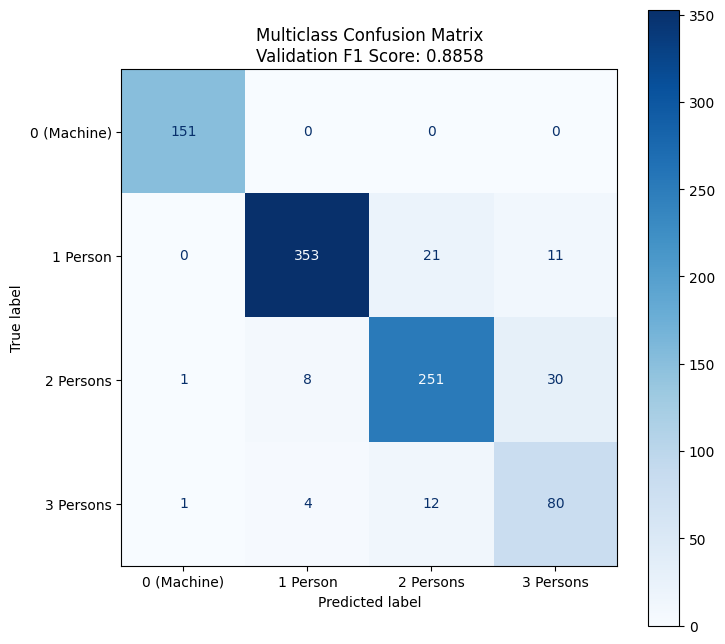

In [29]:
# ==========================================
# --- CELL 1: F1 SCORE & CONFUSION MATRIX ---
# ==========================================
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

print("Evaluating multiclass model on validation data...")

# 1. Get predictions for validation data
# Softmax outputs 4 probabilities per image. argmax picks the index of the highest one (0, 1, 2, or 3).
val_probs = multiclass_model.predict(x_val)
val_preds = np.argmax(val_probs, axis=1)

# 2. Calculate F1 Score
# 'macro' average treats all classes equally, which is great for finding hidden weaknesses
macro_f1 = f1_score(y_val, val_preds, average='macro')
print(f"✅ Multiclass Validation Macro F1 Score: {macro_f1:.4f}")

# 3. Generate and Plot Confusion Matrix
cm = confusion_matrix(y_val, val_preds)

# Display the 4x4 matrix
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['0 (Machine)', '1 Person', '2 Persons', '3 Persons']
)

disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title(f'Multiclass Confusion Matrix\nValidation F1 Score: {macro_f1:.4f}')
plt.show()

In [30]:
# ==========================================
# --- CELL 2: KAGGLE SUBMISSION SAVING ---
# ==========================================
import os
import pandas as pd
import numpy as np

print("Generating Kaggle predictions...")

# 1. Get predictions for the test dataset
test_probs = multiclass_model.predict(x_test)
test_preds = np.argmax(test_probs, axis=1)

# 2. Get the final validation accuracy from the training history
# (Assuming your fit() function output was saved to the variable 'history')
final_val_acc = history.history['val_accuracy'][-1] 
print(f"✅ Predictions complete. Model Validation Accuracy: {final_val_acc:.4f}")

# 3. Create the Kaggle submission dataframe
submission_df = pd.DataFrame({
    'id': test_ids,
    'target': test_preds
})

# 4. Save to CSV for Kaggle to Google Drive
# We add '_multiclass_' to the filename so you can easily distinguish it from your old cascade submissions
existing_files = [f for f in os.listdir(drive_path) if f.startswith('my_kaggle_submission')]
submission_index = len(existing_files) + 1

# Format validation accuracy for filename
v_acc_str = f"{final_val_acc*100:.2f}".replace('.', '-') 
file_path = f'{drive_path}my_kaggle_submission_multiclass_{str(submission_index).zfill(3)}_Vacc_{v_acc_str}.csv'

submission_df.to_csv(file_path, index=False)
print(f"✅ Submission successfully saved to your Google Drive at:\n{file_path}")

Generating Kaggle predictions...
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
✅ Predictions complete. Model Validation Accuracy: 0.8917
✅ Submission successfully saved to your Google Drive at:
/content/drive/MyDrive/ML_project/my_kaggle_submission_multiclass_025_Vacc_89-17.csv
